# CSE2530 Computational Intelligence
## Assignment 3: Reinforcement Learning

|    Group   |           61          |
|------------|----------------------|
| Student A  |        Eva Miesen (5705304) |
| Student B  |        Iasonas Chronis (6167608) |
| Student C  |        Guy Barel (6124607) |
| Student D  |        Miłosz Dudała (6212743) |

#### Imports

In [2]:
"""
You may only use numpy to implement your algorithms
You can make use of any other libraries for miscellaneous functions, e.g. to create the visual aids.
Put all of your imports in this code block.
"""
import matplotlib.pyplot as plt
import numpy as np
import random
from typing import Dict, List
from tqdm import tqdm

"""
The following classes are fully implemented in their own files and you should not change them.
Nonetheless, we encourage you to check how they work; this will help you get started.
"""
from Agent import Agent
from Maze import Maze
from QTable import QTable
from State import State
from Action import Action

#### Seed

In [3]:
# Set seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

## 2. Navigating in the Supermarket
### 2.1 Development
#### Question 1

In [4]:
class ExplorationStrategy:
    def __init__(self, q_table: QTable):
        """
        Initialise the learner with a Q-table.
        
        Args:
            q_table (QTable): The Q-table storing state-action values
        """

        self.q_table = q_table

    def random(self, agent: Agent, maze: Maze):
        """
        The random exploration strategy selects a random action uniformly at random
        from the set of all valid actions.

        Args: 
            agent (Agent): The agent to select an action for
            maze (Maze): The maze to select an action for

        Returns:
            Action: A random valid action
        """
        valid_actions = agent.get_valid_actions(maze)
        return valid_actions[np.random.randint(len(valid_actions))]                         # Randomly select a valid action

    def e_greedy(self, agent: Agent, maze: Maze, eps: float):
        """
        The e-greedy exploration strategy selects a random action with probability eps,
        and the action with highest q-value with probability 1 - eps. A value of epsilon
        close to 0 favours exploitation, while a value close to 1 favours exploration.

        Args:
            agent (Agent): The agent to select an action for
            maze (Maze): The maze to select an action for
            eps (float): The probability of selecting a random action

        Returns:
            Action: A random valid action
        """
        valid_actions = agent.get_valid_actions(maze)

        # Randomly select an action with probability eps
        if np.random.random() < eps:
            return valid_actions[np.random.randint(len(valid_actions))]

        # Select the action with the highest q-value
        state = agent.get_state(maze)
        q_values = np.array([self.q_table.get_q(state, a) for a in valid_actions])
        best_indices = np.where(q_values == q_values.max())[0]                              # A tie-breaker that allows us to select randomly between multiple best actions

        return valid_actions[np.random.choice(best_indices)]

    def boltzmann(self, agent: Agent, maze: Maze, temperature: float):
        """
        The Boltzmann exploration strategy assigns a probability to each action based on its estimated q-values.
        A large value of the temperature encourages exploration, and as the temperature declines over time,
        exploitation is favoured.

        Args:
            agent (Agent): The agent to select an action for
            maze (Maze): The maze to select an action for
            temperature (float): The temperature of the Boltzmann distribution

        Returns:
            Action: A random valid action
        """
        valid_actions = agent.get_valid_actions(maze)
        state = agent.get_state(maze)
        q_values = np.array([self.q_table.get_q(state, a) for a in valid_actions], dtype=float)

        # Subtract max for numerical stability before exponentiation
        q_shifted = q_values - q_values.max()
        exp_q = np.exp(q_shifted / temperature)
        probabilities = exp_q / exp_q.sum()
        chosen_idx = np.random.choice(len(valid_actions), p=probabilities)
        
        return valid_actions[chosen_idx]

**Random exploration** selects a valid action uniformly at random, every valid action has equal probability of being chosen. This ensures maximum exploration, but ignores any learned information, making it inefficient once the agent starts accumulating knowledge.

**ε-greedy exploration** selects a random action with probability $ε$ (exploration) and the highest-Q action with probability $1 − ε$ (exploitation). It provides a simple and effective balance between the two. `ε = 0.1` is used as the initial value, so the agent explores 10% of the time, while mostly following what it has learned.

**Boltzmann exploration** (softmax) assigns probabilities to all valid actions proportional to their exponentiated Q-values scaled by temperature T:
- High T → near-uniform distribution (exploration)
- Low T → probability concentrated on the best action (exploitation)

Unlike **ε-greedy**, it considers relative Q-value magnitudes when exploring, making it a softer tradeoff. `T = 1.0` is used as the initial temperature.

To ensure sufficient exploration in early episodes and increasing exploitation over time, both `ε` and `T` can be decayed during training. This motivates the exploration-heavy start that allows the agent to discover the goal, followed by convergence to the optimal policy as knowledge is refined.

#### Question 2

In [5]:
def run_single_run(maze_path, goal_x, goal_y, n_steps, learner=None, strategy='e_greedy',
                    eps=0.1, temperature=1.0):
    """
    Runs one complete training run, stopping when total steps across all episodes >= n_steps.
    Returns a list of episode lengths (steps per episode).
    
    Args:
        maze_path (str): The path to the maze file
        goal_x (int): The x-coordinate of the goal
        goal_y (int): The y-coordinate of the goal
        n_steps (int): The maximum number of steps to run
        learner (QLearning or SARSA): The learning algorithm to use
        strategy (str): The exploration strategy to use
        eps (float): The probability of selecting a random action
        temperature (float): The temperature of the Boltzmann distribution

    Returns:
        list: A list of episode lengths (steps per episode)
    """
    maze = Maze(maze_path)
    maze.set_reward(x=goal_x, y=goal_y, reward=10)
    maze.set_terminal(x=goal_x, y=goal_y)
    agent = Agent(start_x=0, start_y=0)
    actions = [Action(a_id) for a_id in ["up", "down", "left", "right"]]
    q_table = QTable(maze.get_all_states(), actions)
    strat = ExplorationStrategy(q_table)
    if learner is not None:
        learner.q_table = q_table

    episode_lengths = []
    total_steps = 0

    # Main training loop
    while total_steps < n_steps:
        agent.reset()
        done = False

        # Episode loop
        while not done:
            state = agent.get_state(maze)

            # Select action according to the chosen strategy
            if strategy == 'random':
                action = strat.random(agent, maze)
            elif strategy == 'boltzmann':
                action = strat.boltzmann(agent, maze, temperature)
            else:
                action = strat.e_greedy(agent, maze, eps)                                   # Default: e_greedy

            # Execute action in the environment
            next_state, reward, done = agent.step(action, maze)

            if learner is not None:
                valid_actions = agent.get_valid_actions(maze)
                if learner.__class__.__name__ == "QLearning":
                    learner.learn(valid_actions, state, action, next_state, reward, done)
                elif learner.__class__.__name__ == "SARSA":                                 # If SARSA, then next_action (a') needs to be calculated. That is done as follows:
                    old_x, old_y = agent.x, agent.y                                         # Save agent's current position
                    agent.x, agent.y = next_state.x, next_state.y                           # Move agent to the next_state
                    
                    next_action = strat.e_greedy(agent, maze, eps)                          # Choose next action using the same policy (e.g., e_greedy)
                    agent.x, agent.y = old_x, old_y                                         # Restore agent's original position
                    learner.learn(state, action, next_state, next_action, reward, done)
            total_steps += 1
            
        episode_lengths.append(agent.nr_of_actions_since_reset)

    return episode_lengths

In [6]:
# Create a Maze instance
maze = Maze("./../data/toy_maze.txt")                                                       # Changed from easy_maze.txt to toy_maze.txt
maze.set_reward(x=9, y=9, reward=10)
maze.set_terminal(x=9, y=9)

# Create an Agent
agent = Agent(start_x=0, start_y=0)

# Create a QTable
states = maze.get_all_states()
actions = [Action(id) for id in ["up", "down", "left", "right"]]
q_table = QTable(states, actions)

# Create an ExplorationStrategy
exploration_strategy = ExplorationStrategy(q_table)

# Create a learner
params = {"lr": 0.7, "gamma": 0.9}                                                          # learner = QLearning(q_table, params)

# Hyper-parameters
n_episodes = 300
episode_lengths = []
episode_rewards = []

for episode in tqdm(range(n_episodes)):
    # Reset the agent to the start position at the beginning of each episode
    agent.reset()
    done = False
    episode_reward = 0

    # Iterate until the agent reaches the goal
    while not done:
        # Observation: Where am I?
        state = agent.get_state(maze)

        # Decision: What to do?
        action = exploration_strategy.e_greedy(agent, maze, eps=0.1)

        # Execution: Move and observe
        next_state, reward, done = agent.step(action, maze)
        
        episode_reward += reward                                                            # No learner, Q-table is not updated here
    
    # Store the episode length and reward
    episode_lengths.append(agent.nr_of_actions_since_reset)
    episode_rewards.append(episode_reward)

100%|██████████| 300/300 [00:04<00:00, 74.89it/s]


The agent cycle consists of the following steps, which repeat until an episode terminates:

1. **Reset:** At the start of each episode the agent is placed back at its starting position. This is necessary to begin a fresh trial from a consistent state.
2. **Get current state:** The agent reads its current `(x, y)` position in the maze. This is needed because the action selection and Q-table update both depend on knowing the current state.
3. **Select action:** An action is chosen using the exploration strategy (here `ε-greedy`). This maps the current state to an action via the policy $π$, which is how the agent decides what to do next.
4. **Execute action:** `agent.step(action, maze)` moves the agent and returns `(next_state, reward, done)`. This step is the agent's interaction with its environment, it receives feedback in the form of a reward and a new state.
5. **Update Q-table** (omitted here, no learner yet)**:** In later questions, this is where the learning algorithm updates $Q(s, a)$ based on the observed transition, without it the agent cannot improve.
6. **Record episode length:** After the episode ends (terminal state reached), the number of steps taken is stored, this is used to monitor learning progress.

No additional steps are needed, the `Agent` class internally tracks position and step count, `Maze` handles reward and terminal queries, and `QTable` stores Q-values. These responsibilities are cleanly separated, so the cycle itself only needs to orchestrate them.

#### Question 3

In [7]:
# Run the agent with a step budget
N_STEPS = 30_000
toy_maze_path = "./../data/toy_maze.txt"

episode_lengths_q3 = run_single_run(
    maze_path=toy_maze_path,
    goal_x=9,
    goal_y=9,
    n_steps=N_STEPS,
    strategy='e_greedy',
    eps=0.1
)

total_steps_taken = sum(episode_lengths_q3)

# Print the results
print(f"Number of episodes completed: {len(episode_lengths_q3)}")
print(f"Total steps taken: {total_steps_taken}")
print(f"Step budget (n_steps): {N_STEPS}")
print(f"Overshoot (last episode): {total_steps_taken - N_STEPS}")

Number of episodes completed: 19
Total steps taken: 32662
Step budget (n_steps): 30000
Overshoot (last episode): 2662


The stopping criterion is implemented in the `run_single_run` helper. A `total_steps` counter is incremented at each step and the outer loop exits as soon as `total_steps >= n_steps`. Because the budget is checked after each step (and the agent is always allowed to fully finish the episode it is on), the total will exceed `n_steps` by a fraction of the length of that final episode. Running the agent with `n_steps = 30,000` on the toy maze confirms this, the printed total is > 30,000, with the overshoot representing the number of steps that last episode dragged on past our budget. The large step budget relative to the maze size ensures the agent completes many episodes before stopping.

#### Question 4

In [8]:
def run_experiment(maze_path, goal_x, goal_y, n_steps, n_runs,
                   learner=None, strategy='e_greedy', eps=0.1, temperature=1.0):
    """
    Runs n_runs independent runs (each up to n_steps total steps) and returns a
    list of episode-length lists, one per run.

    Args:
        maze_path (str): The path to the maze file
        goal_x (int): The x-coordinate of the goal
        goal_y (int): The y-coordinate of the goal
        n_steps (int): The maximum number of steps to run
        n_runs (int): The number of independent runs to perform
        learner (QLearning or SARSA): The learning algorithm to use
        strategy (str): The exploration strategy to use
        eps (float): The probability of selecting a random action
        temperature (float): The temperature of the Boltzmann distribution

    Returns:
        list: A list of episode-length lists, one per run
    """
    
    all_lengths = []

    # Run the experiment n_runs times
    for _ in range(n_runs):
        lengths = run_single_run(
            maze_path=maze_path,
            goal_x=goal_x,
            goal_y=goal_y,
            n_steps=n_steps,
            learner=learner,
            strategy=strategy,
            eps=eps,
            temperature=temperature
        )
        all_lengths.append(lengths)

    return all_lengths


def pad_and_aggregate(all_lengths):
    """
    Pads runs to the same length with NaN, then returns per episode mean and std.
    Runs with fewer episodes contribute NaN, so nanmean/nanstd ignore them.

    Args:
        all_lengths (list): A list of episode-length lists, one per run

    Returns:
        tuple: A tuple containing the mean and standard deviation of the episode lengths
    """

    # Find the maximum number of episodes across all runs
    max_ep = max(len(r) for r in all_lengths)

    # Create a padded array with NaN values
    padded = np.full((len(all_lengths), max_ep), np.nan)

    # Pad runs to the same length with NaN
    for i, r in enumerate(all_lengths):
        padded[i, :len(r)] = r

    mean = np.nanmean(padded, axis=0)
    std = np.nanstd(padded, axis=0)

    return mean, std

Toy maze:
  run 1: [2594, 308, 1990, 1488, 762, 1524, 660, 5442, 592, 908, 1876, 364, 1130, 1662, 752, 786, 534, 994, 1816, 3410, 694]
  run 2: [622, 290, 2940, 816, 572, 506, 310, 1886, 294, 3318, 932, 312, 356, 1160, 342, 1848, 884, 3084, 938, 2262, 2848, 1376, 1070, 3146]
  run 3: [2576, 468, 492, 180, 1410, 638, 186, 2054, 1494, 652, 238, 1468, 622, 460, 1110, 1178, 878, 2238, 922, 292, 1646, 526, 664, 594, 798, 680, 828, 1626, 618, 2126, 3208]
  run 4: [1104, 862, 152, 494, 668, 818, 3432, 1456, 132, 2336, 562, 272, 1982, 2456, 350, 260, 4778, 2840, 986, 532, 428, 224, 990, 948, 488, 1130]
  run 5: [322, 484, 1626, 3230, 636, 876, 1346, 484, 776, 3494, 1578, 144, 2524, 1288, 586, 480, 246, 958, 1842, 566, 1812, 2182, 700, 1862]
  run 6: [278, 356, 220, 572, 502, 284, 824, 760, 2060, 1724, 1680, 792, 236, 766, 1310, 3688, 608, 2704, 1994, 3876, 1424, 1698, 652, 322, 6888]
  run 7: [2460, 1000, 5056, 962, 576, 832, 1796, 490, 1114, 1388, 362, 936, 262, 636, 1434, 302, 1520, 420, 104

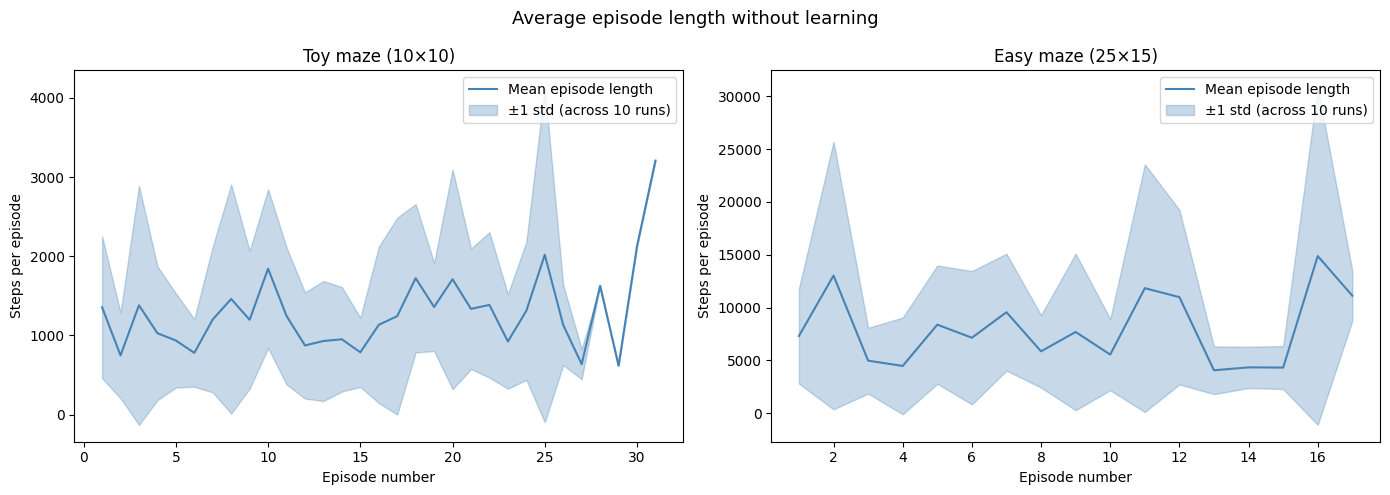

In [9]:
N_RUNS = 10
N_STEPS_TOY  = 30_000
N_STEPS_EASY = 100_000                      # Larger maze needs more steps

toy_path  = "./../data/toy_maze.txt"
easy_path = "./../data/easy_maze.txt"

# Run experiments
toy_lengths  = run_experiment(toy_path,  goal_x=9,  goal_y=9,  n_steps=N_STEPS_TOY,  n_runs=N_RUNS)
easy_lengths = run_experiment(easy_path, goal_x=24, goal_y=14, n_steps=N_STEPS_EASY, n_runs=N_RUNS)

# Print the episode lengths per run
print("Toy maze:")
for i, ep_lens in enumerate(toy_lengths):
    print(f"  run {i+1}:", ep_lens)

print("Easy maze:")
for i, ep_lens in enumerate(easy_lengths):
    print(f"  run {i+1}:", ep_lens)

toy_mean,  toy_std  = pad_and_aggregate(toy_lengths)
easy_mean, easy_std = pad_and_aggregate(easy_lengths)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Average episode length without learning", fontsize=13)

# Plot the results
for ax, mean, std, title, n_ep in [
    (axes[0], toy_mean,  toy_std,  "Toy maze (10×10)",  len(toy_mean)),
    (axes[1], easy_mean, easy_std, "Easy maze (25×15)", len(easy_mean)),
]:
    episodes = np.arange(1, n_ep + 1)
    ax.plot(episodes, mean, label="Mean episode length", color="steelblue")
    ax.fill_between(episodes, mean - std, mean + std, alpha=0.3,
                    color="steelblue", label="±1 std (across 10 runs)")
    ax.set_title(title)
    ax.set_xlabel("Episode number")
    ax.set_ylabel("Steps per episode")
    ax.legend()

plt.tight_layout()
plt.show()

The plots above show the average number of steps per episode across 10 independent runs, with the shaded region indicating ±1 standard deviation.

As expected, without a learning algorithm the episode lengths show **no decreasing trend**, they remain high and noisy throughout training. This is because the Q-table is never updated. All Q-values stay at their initial value of zero, so the ε-greedy strategy effectively selects actions randomly. The agent therefore cannot exploit past experience to shorten its path to the goal.

For the toy maze, the average episode is very long relative to the optimal path, and the variance is high since the random walk may take very different routes each time. The easy maze shows similarly erratic behaviour, but with even longer episodes due to its larger size and more complex structure.

The shaded bands capture inter-run variability. Where runs produce different numbers of episodes (due to variation in episode length), shorter runs are padded with `NaN` so that the mean is computed only over available runs at each episode index, this keeps the plot meaningful even when episode counts differ across runs.

#### Question 5

In [10]:
# Hyperparameters
alpha = 0.7
gamma = 0.9
epsilon = 0.1

In [11]:
class QLearning:

    def __init__(self, q_table: QTable, params: Dict[str, float]) -> None:
        """
        Initialize a QLearning instance with a Q-table and learning parameters.

        Args:
            q_table (QTable): The Q-table object to be updated during learning
            params (dict): A dictionary containing the learning parameters:
                - 'alpha' (float): Learning rate
                - 'gamma' (float): Discount factor
        """

        self.q_table = q_table
        self.params = params

    def learn(self, possible_actions: List[Action], state: State, action: Action,
               next_state: State, reward: int, done: bool) -> None:
        
        """
        Update the Q-value for the current state-action pair using the Q-Learning rule.

        Args:
            possible_actions (List[Action]): All valid actions available from the next state
            state (State): The current state before taking the action
            action (Action): The action taken in the current state
            next_state (State): The state resulting from taking the action
            reward (int): The reward received for taking the action
            done (bool): True if the next_state is terminal, False otherwise
        """
        
        old_value = self.q_table.get_q(state, action)                                           # Get old value of current state from the table
        
        if done:
            next_state_value = 0                                                                # If terminal state, value is 0
        else: 
            next_state_value = max(self.q_table.get_q(next_state, a)                            # Take the best future value for a in possible_actions)
                                     for a in possible_actions)             
                                    
        new_value = old_value + alpha * (reward + (gamma * next_state_value) - old_value)       # Calculate new_value using equation 1.1
        self.q_table.set_q(state, action, new_value)                                            # Set new_value in table

In [12]:
class SARSA:

    def __init__(self, q_table: QTable, params: Dict[str, float]) -> None:
        """
        Initialize a SARSA instance with a Q-table and learning parameters.

        Args:
            q_table (QTable): The Q-table object to be updated during learning
            params (dict): A dictionary containing the learning parameters:
                - 'alpha' (float): Learning rate
                - 'gamma' (float): Discount factor
        """

        self.q_table = q_table
        self.params = params
    
    def learn(self, state: State, action: Action, next_state: State, next_action: Action,
               reward: float, done: bool) -> None:
        """
        Update the Q-value for the current state-action pair using the SARSA update rule.

        Args:
            state (State): The current state before taking the action
            action (Action): The action taken in the current state
            next_state (State): The state resulting from taking the action
            next_action (Action): The next action selected from the next_state using the agent's policy (on-policy)
            reward (float): The reward received for taking the action
            done (bool): True if the next_state is terminal, False otherwise
        """
        
        old_value = self.q_table.get_q(state, action)                                       # Get old value of current state from the table

        if done:                                                                            # If terminal state, value is 0
            next_state_value = 0                                                    
        else:
            next_state_value = self.q_table.get_q(next_state, next_action)                  # Take the value of the next state and next action
        
        new_value = old_value + alpha * (reward + (gamma * next_state_value) - old_value)   # SARSA update using equation 1.2
        self.q_table.set_q(state, action, new_value)                                        # Store new_value in table

The `QLearning` class implements the Q-learning algorithm, which is an off-policy learning method. It is termed off-policy, because it uses the greedy estimate $max_{a'}Q(s', a')$ for the next state, regardless of the policy used to select actions. The algorithm maintains a Q-table that stores the estimated values $Q(s, a)$ for each state-action pair. The `learn()` method updates the Q-values using equation 1.1; $Q(s, a) \leftarrow Q(s, a) + a(r - \gamma * max_{a'}Q(s', a') - Q(s, a))$.

The Q-learning algorithm procedure is:

1. Retrieve the current Q-value for the state-action pair.
2. If the next state is terminal, the future value is 0. Otherwise, take the maximum Q-value over all possible next actions.
3. Update the current Q-value according to equation 1.1.

The `SARSA` (State-Action-Reward-next State-next Action) class implements the SARSA algorithm, which is an on-policy method. Being on-policy means that the algorithm evaluates and improves the policy that is actually followed by the agent. Like Q-learning, it also maintains a Q-table of state-action values. The `learn()` method updates the Q-values using equation 1.2; $Q(s, a) \leftarrow Q(s, a) + a (r + \gamma * Q(s', a') - Q(s, a))$.

The SARSA algorithm procedure is:

1. Retrieve the current Q-value for the state-action pair.
2. If the next state is terminal, the future value is 0. Otherwise, use the Q-value of the next action actually chosen by the agent's policy.
3. Update the current Q-value according to equation 1.2.

Both algorithms use the hyperparameters $𝛼$ = 0.7, $𝛾$ = 0.9 and $\epsilon$ = 0.1 for an $\epsilon$-greedy exploration policy.

#### Question 6

In [13]:
def prep_states_action(path: str, goal_x: int, goal_y: int):
    """
    Prepares the Q-table and learning parameters for a given maze and goal position.

    This function:
        - Loads the maze from the given file path.
        - Sets the terminal state at the specified goal coordinates.
        - Collects all walkable states (excluding walls) from the maze.
        - Defines the possible actions for the agent.
        - Creates a Q-table initialised with the states and actions.
        - Returns default learning parameters (alpha and gamma).

    Args:
        path (str): The file path to the maze text file
        goal_x (int): The x-coordinate of the goal (terminal) state
        goal_y (int): The y-coordinate of the goal (terminal) state

    Returns:
        tuple:
            - QTable: A Q-table object initialised with states and actions
            - dict: A dictionary of learning parameters containing:
                - 'alpha' (float): Learning rate for updates
                - 'gamma' (float): Discount factor for future rewards
    """
    
    maze = Maze(path)
    maze.set_terminal(goal_x, goal_y)
    states = [s for s in maze.get_all_states() if s.type == "path"]
    actions = [Action(a_id) for a_id in ["up", "down", "left", "right"]]
    q_table = QTable(states, actions)
    params = {"alpha": 0.1, "gamma": 0.99}
    return q_table, params

In [14]:
# Run agent with QLearning on the mazes, average of 10 runs each

def make_qlearner(q_table: QTable, params: Dict[str, float]):
    """
    Create a fresh QLearning learner using the provided Q-table and parameters.

    Args:
        q_table (QTable): The Q-table storing state-action values
        params (dict): A dictionary containing learning parameters:
            - 'alpha' (float): Learning rate
            - 'gamma' (float): Discount factor

    Returns:
        QLearning: An instance of the QLearning algorithm
    """

    return QLearning(q_table, params)

def run_with_qlearning(path: str, goal_x: int, goal_y: int, n_steps: int):
    """
    Runs multiple independent Q-learning training runs on a given maze and returns
    a list of episode-length lists, one per run.

    Each run uses a fresh Q-table and learner instance, and episodes continue
    until the cumulative number of steps reaches `n_steps`.

    Args:
        path (str): Path to the maze file.
        goal_x (int): X-coordinate of the goal (terminal) state
        goal_y (int): Y-coordinate of the goal (terminal) state
        n_steps (int): Maximum number of steps across all episodes for each run

    Returns:
        list: A list of episode-length lists (steps per episode), one list per run
    """
    
    all_lengths = []
    for _ in range(N_RUNS):         
        q_table, params = prep_states_action(path, goal_x, goal_y)    # Prepare the q_table and parameters (alpha and gamma)
        learner = make_qlearner(q_table, params)                      # Fresh learner each run
        lengths = run_single_run(
            maze_path=path,
            goal_x=goal_x,
            goal_y=goal_y,
            n_steps=n_steps,
            learner=learner,
            strategy='e_greedy',
            eps=epsilon
        )
        all_lengths.append(lengths)
    return all_lengths

q_toy_lengths  = run_with_qlearning(toy_path,  9,  9,  N_STEPS_TOY)
q_easy_lengths = run_with_qlearning(easy_path, 24, 14, N_STEPS_EASY)

In [15]:
# Run agent with SARSA on the mazes, average of 10 runs each

def make_slearner(q_table: QTable, params: Dict[str, float]):
    """
    Create a fresh SARSA learner using the provided Q-table and parameters.

    Args:
        q_table (QTable): The Q-table storing state-action values
        params (dict): A dictionary containing learning parameters:
            - 'alpha' (float): Learning rate
            - 'gamma' (float): Discount factor

    Returns:
        SARSA: An instance of the SARSA algorithm
    """

    return SARSA(q_table, params)

def run_with_sarsa(path: str, goal_x: int, goal_y: int, n_steps: int):
    """
    Runs multiple independent SARSA training runs on a given maze and returns
    a list of episode-length lists, one per run.

    Each run uses a fresh Q-table and learner instance, and episodes continue
    until the cumulative number of steps reaches `n_steps`.

    Args:
        path (str): Path to the maze file
        goal_x (int): X-coordinate of the goal (terminal) state
        goal_y (int): Y-coordinate of the goal (terminal) state
        n_steps (int): Maximum number of steps across all episodes for each run

    Returns:
        list: A list of episode-length lists (steps per episode), one list per run
    """
    
    all_lengths = []
    for _ in range(N_RUNS):
        q_table, params = prep_states_action(path, goal_x, goal_y)      # Prepare the q_table and parameters (alpha and gamma)
        learner = make_slearner(q_table, params)                        # Fresh learner each run
        lengths = run_single_run(
            maze_path=path,
            goal_x=goal_x,
            goal_y=goal_y,
            n_steps=n_steps,
            learner=learner,
            strategy='e_greedy',
            eps=epsilon
        )
        all_lengths.append(lengths)
    return all_lengths

s_toy_lengths  = run_with_sarsa(toy_path,  9,  9,  N_STEPS_TOY)
s_easy_lengths = run_with_sarsa(easy_path, 24, 14, N_STEPS_EASY)

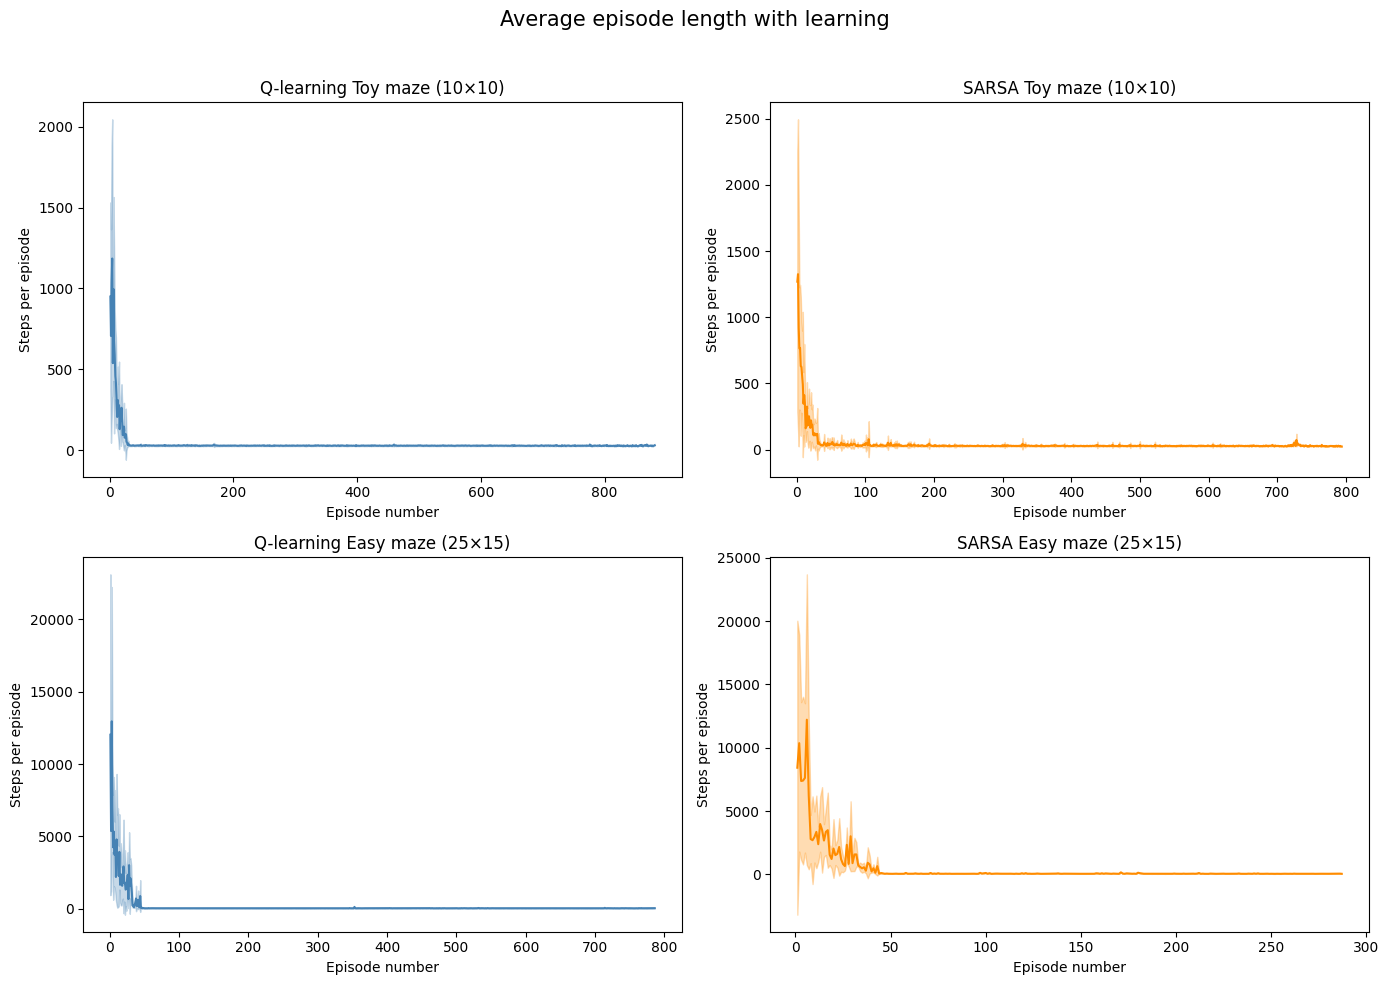

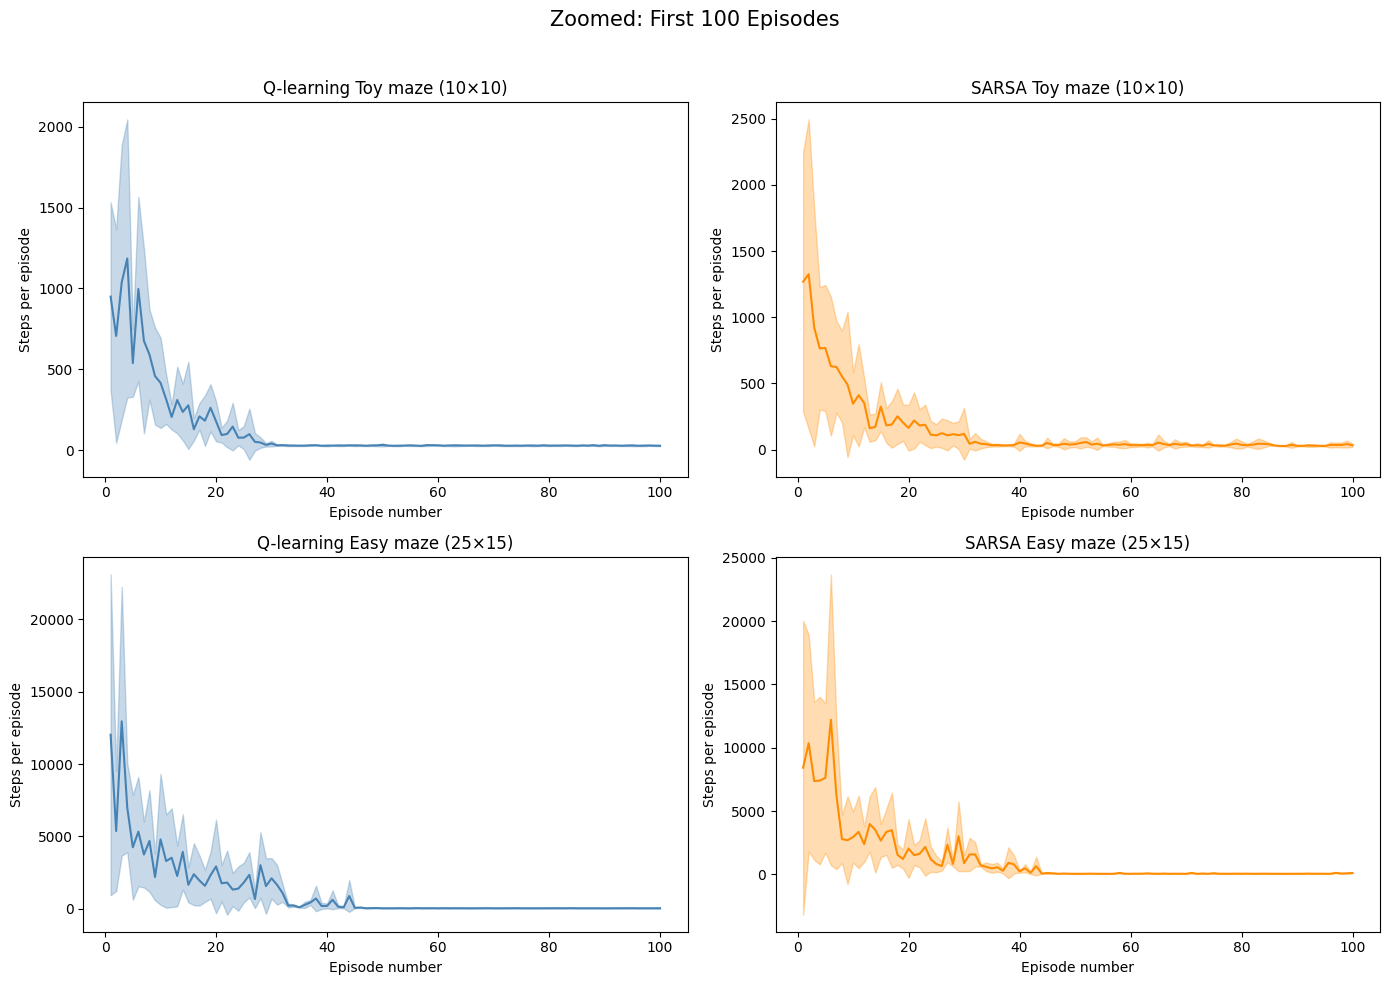

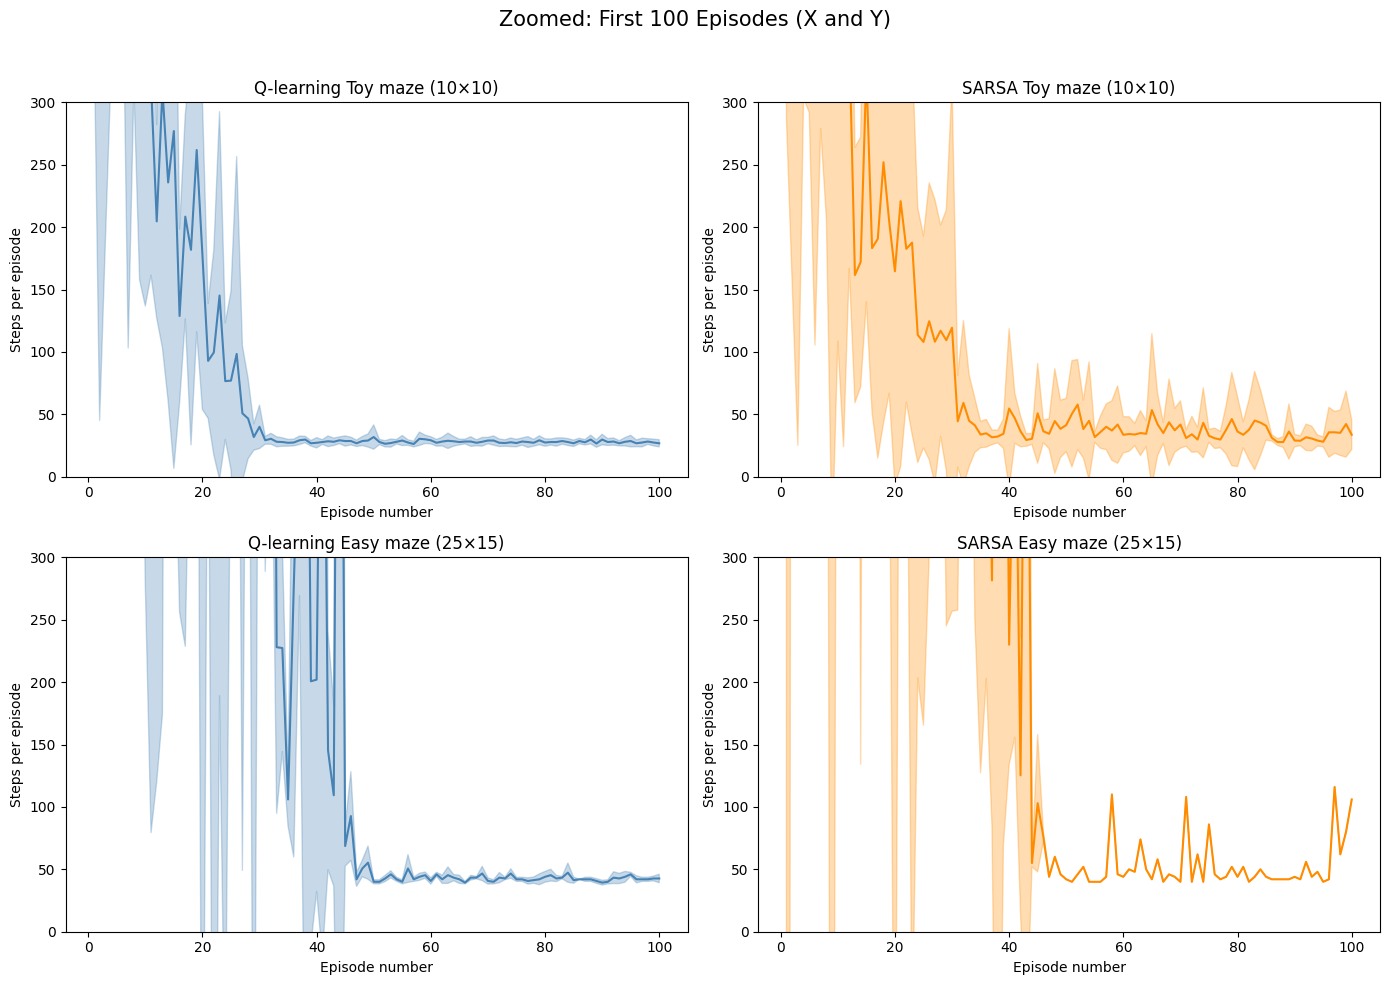

In [ ]:
# Calculate the mean and standard deviation
q_toy_mean,  q_toy_std  = pad_and_aggregate(q_toy_lengths)
q_easy_mean, q_easy_std = pad_and_aggregate(q_easy_lengths)

s_toy_mean,  s_toy_std  = pad_and_aggregate(s_toy_lengths)
s_easy_mean, s_easy_std = pad_and_aggregate(s_easy_lengths)

def plot_maze_results(maze_data, title, zoom_x=None, zoom_y=None):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(title, fontsize=15)

    axes_flat = axes.flatten()

    for ax, (mean, std, subplot_title) in zip(axes_flat, maze_data):
        episodes = np.arange(1, len(mean) + 1)
        color = "steelblue" if "Q-learning" in subplot_title else "darkorange"

        # Apply x zoom if requested
        if zoom_x is not None:
            episodes = episodes[:zoom_x]
            mean = mean[:zoom_x]
            std = std[:zoom_x]

        ax.plot(episodes, mean, color=color)
        ax.fill_between(episodes, mean - std, mean + std,
                        alpha=0.3, color=color)

        if zoom_y is not None:
            ax.set_ylim(0, zoom_y)

        ax.set_title(subplot_title)
        ax.set_xlabel("Episode number")
        ax.set_ylabel("Steps per episode")

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

maze_data = [
    (q_toy_mean, q_toy_std, "Q-learning Toy maze (10×10)"),
    (s_toy_mean, s_toy_std, "SARSA Toy maze (10×10)"),
    (q_easy_mean, q_easy_std, "Q-learning Easy maze (25×15)"),
    (s_easy_mean, s_easy_std, "SARSA Easy maze (25×15)")
]

# Hyperparameters
zoom_x = 100
zoom_y = 300

# Full training
plot_maze_results(maze_data, "Average episode length with learning")

# Zoom on first 100 episodes
plot_maze_results(maze_data, "Zoomed: First 100 Episodes", zoom_x=zoom_x)

# Zoom on first 100 episodes + y-axis
plot_maze_results(maze_data, "Zoomed: First 100 Episodes (X and Y)", zoom_x=zoom_x, zoom_y=zoom_y)


The plots above show the average episode lengths of the agent over multiple runs for Q-learning and SARSA on the Toy maze (10x10) and Easy maze (25x15). In each plot, the x-axis represents the episode number and the y-axis represents the number of steps per episode. The line represents the mean number of steps, while the shaded regions indicate the standard deviation, reflecting the uncertainty in performance across runs. The first four plots show the whole learning phase of the agents, while the last four plots are zoomed in on the first 100 episodes of the learning process to ensure a more detailed view of both learning algorithms. "Learning" in this context means that the agent improves its policy over time, resulting in shorter paths (and thus fewer steps) to the goal.

The following pieces of evidence suggest that the agent is learning the environment:
- **Average number of steps per episode decreases**: In all plots, there is a clear downward trend in the number of steps per episode as episodes progress. (TODO: give specifics!) This demonstrates that the agents are learning to reach the goal more efficiently over time.
- **The curve stabilises at a low value**: The average number of steps per episode differs a lot between episodes at the beginning, but then converges to a low value, indicating that the agent has converged to a consistent policy.
- **Uncertainty band narrows**: Initially, the shaded regions that show the variance over runs are wide, indicating that different runs take different paths due to exploration ($\epsilon$-greedy strategy). As learning progresses, the variance shrinks, showing that the agent consistently selects near-optimal paths and suggests that different runs converge to similar performance. The reward structure encourages the agent to reach the terminal quickly, which drives the reduction in steps per episode.

#### Question 7: Do you observe any differences between robots trained using QLearning and SARSA? Why is that the case?

#TODO: more specific -> use details from the graph; number of episodes, which learning algorithm converges first (mention where)

The following differences between robots trained using Q-learning and SARSA are observed:
- **Convergence speed**: Q-learning agents tend to reach shorter episode lengths faster than SARSA. In both mazes, the Q-learning curves drop more sharply at the start (#TODO: SPECIFY EXACLTY WHERE!!), indicating that the agent finds efficient paths to the goal sooner. This reflects the off-policy nature of Q-learning, where updates consider the maximum future Q-value ($max_{a'} Q(s', a')$), allowing the agent to optimistically assume it will always take the best next action.
- **Sensitivity to exploration**: SARSA shows slightly more gradual reductions in episode length and higher early variance. Since it is on-policy, SARSA updates its Q-values using the action actually chosen by the policy ($Q(s',a')$), incorporating exploratory moves from the ε-greedy strategy. This means exploratory moves directly influence learning, producing safer, but sometimes longer, paths during early episodes.
- **Path consistency**: SARSA usually follows more predictable paths, because it learns from the actions it actually takes, while Q-learning can take riskier paths at first, since it assumes it will always pick the best action.
- **Long-term performance**: Both agents eventually converge to near-optimal paths, but Q-learning reaches this point faster. SARSA maintains slightly higher variability in early episodes because exploration directly affects its Q-value updates.

### 2.2 Optimization
#### Question 8

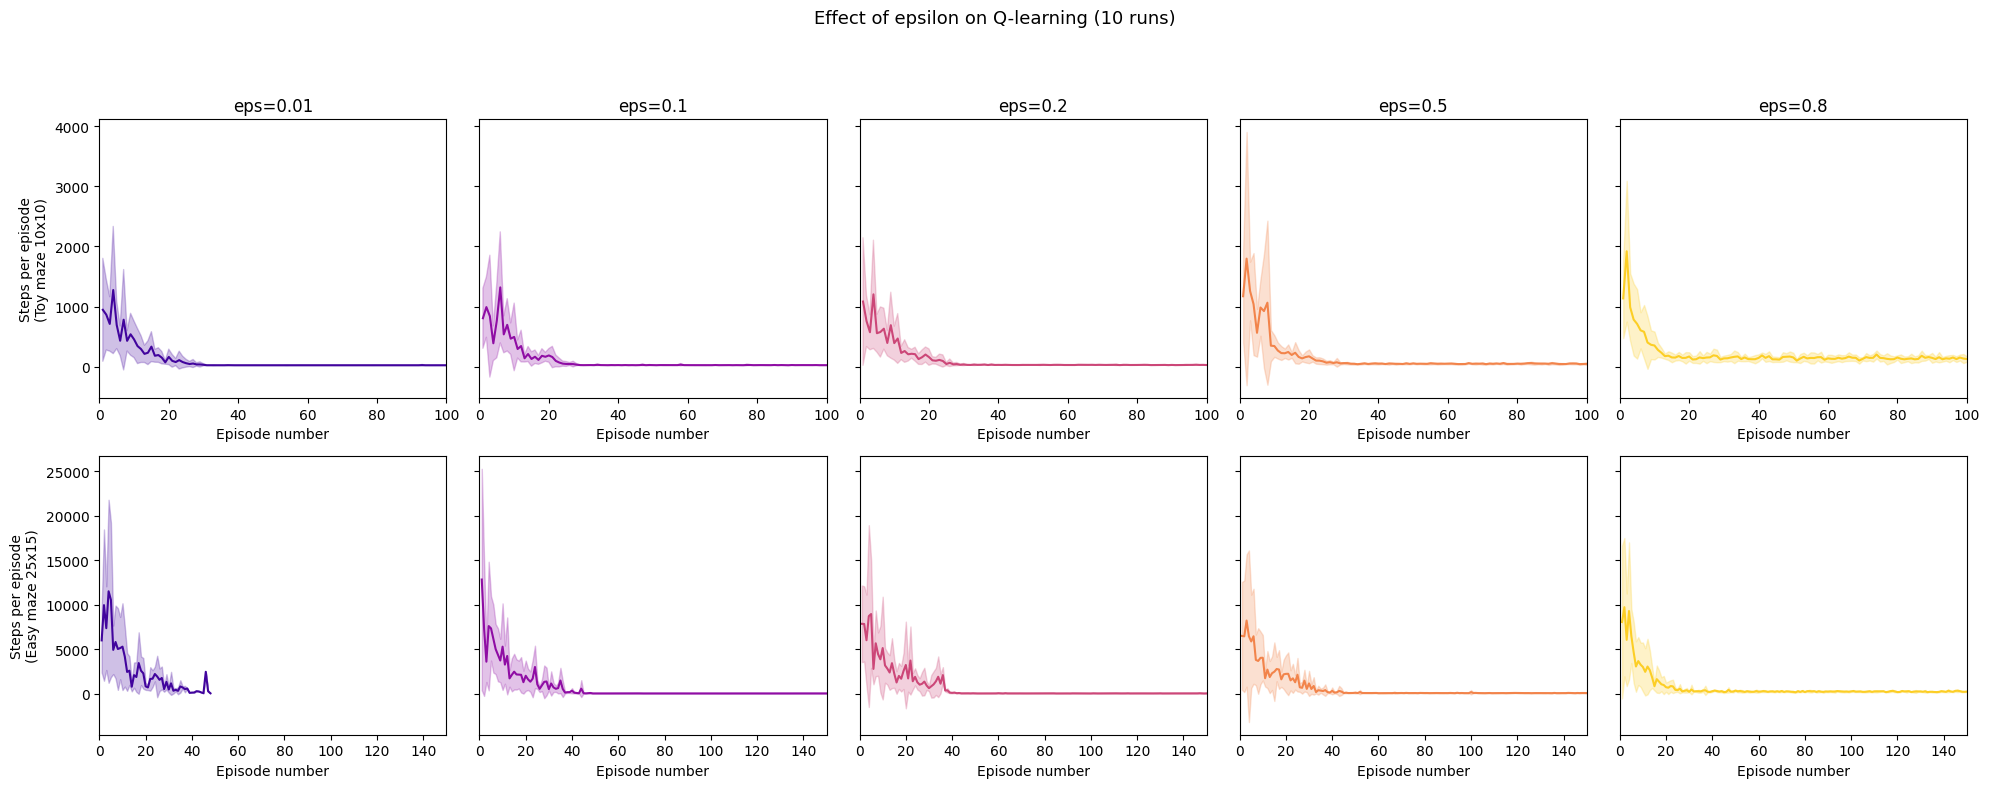

In [17]:
# Varying epsilon values for e-greedy strategy
epsilon_values = [0.01, 0.1, 0.2, 0.5, 0.8]

eps_results_toy = {}
eps_results_easy = {}

# For each epsilon value, run the experiment and store the results for both mazes
for ev in epsilon_values:
    q_table, params = prep_states_action(toy_path, 9, 9)
    learner = make_qlearner(q_table, params)
    eps_results_toy[ev] = run_experiment(
        toy_path, goal_x=9, goal_y=9,
        n_steps=N_STEPS_TOY, n_runs=N_RUNS,
        learner=learner, strategy='e_greedy', eps=ev
    )

    q_table, params = prep_states_action(easy_path, 24, 14)
    learner = make_qlearner(q_table, params)
    eps_results_easy[ev] = run_experiment(
        easy_path, goal_x=24, goal_y=14,
        n_steps=N_STEPS_EASY, n_runs=N_RUNS,
        learner=learner, strategy='e_greedy', eps=ev
    )

# Plot: 2 rows (toy, easy) x 5 columns (epsilon values)
fig, axes = plt.subplots(2, len(epsilon_values), figsize=(20, 8), sharey='row')
colors_eps = plt.cm.plasma(np.linspace(0.1, 0.9, len(epsilon_values)))

for col, (color, ev) in enumerate(zip(colors_eps, epsilon_values)):
    # Toy maze (top row)
    mean, std = pad_and_aggregate(eps_results_toy[ev])
    episodes = np.arange(1, len(mean) + 1)
    axes[0, col].plot(episodes, mean, color=color, linewidth=1.5)
    axes[0, col].fill_between(episodes, mean - std, mean + std, alpha=0.25, color=color)
    axes[0, col].set_title(f'eps={ev}')
    axes[0, col].set_xlabel('Episode number')
    axes[0, col].set_xlim(0, 100)

    # Easy maze (bottom row)
    mean, std = pad_and_aggregate(eps_results_easy[ev])
    episodes = np.arange(1, len(mean) + 1)
    axes[1, col].plot(episodes, mean, color=color, linewidth=1.5)
    axes[1, col].fill_between(episodes, mean - std, mean + std, alpha=0.25, color=color)
    axes[1, col].set_xlabel('Episode number')
    axes[1, col].set_xlim(0, 150)

axes[0, 0].set_ylabel('Steps per episode\n(Toy maze 10x10)')
axes[1, 0].set_ylabel('Steps per episode\n(Easy maze 25x15)')
fig.suptitle('Effect of epsilon on Q-learning (10 runs)', fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

*The plots show the average steps per episode over 10 runs, with α=0.7, γ=0.9.*

### Toy Maze (10x10)

**Observations:**

- **ε=0.01:** The agent converges quickly but starts with high variance across runs (wide confidence band), suggesting inconsistent early exploration. Once it finds a path it commits to it fast due to its strong greedy behaviour.
- **ε=0.1 and ε=0.2:** Both show a clear spike in early episodes followed by smooth and fast convergence to near-zero steps. This reflects a good exploration-exploitation balance enough randomness to discover good paths, enough greediness to exploit them.
- **ε=0.5:** Convergence is slightly slower but still reaches a low stable value. The confidence band is wider throughout, indicating more variability across runs.
- **ε=0.8:** The agent converges last among all configurations and stabilises at a noticeably higher step count than lower ε values, as persistent random actions prevent it from fully exploiting its learned policy.

### Easy Maze (25x15)

**Observations:**

- The same general trend holds, all ε values lead to learning, but the effect of ε is higher due to the larger state space requiring more exploration to cover.
- **ε=0.01:** Converges very quickly in terms of episode number but the final stable step count is higher than in the toy maze, suggesting the agent locks into a suboptimal path early due to insufficient exploration of the larger maze.
- **ε=0.1 and ε=0.2:** Show the clearest learning curves with a sharp early drop and stable convergence. These again appear to be the best-performing values.
- **ε=0.5 and ε=0.8:** Take significantly more episodes to converge compared to the toy maze, and the confidence bands remain wide for longer. The easy maze has more states to explore randomly, so high ε hurts convergence more severely here than in the smaller maze.


The value of ε directly controls the **exploration-exploitation trade-off**:

- A **low ε** causes the agent to exploit early, leading to fast convergence but risking commitment to a **suboptimal policy**, especially in larger mazes where good paths may require more exploration to discover.
- A **high ε** ensures thorough exploration of the state space, but the agent **never fully commits** to its learned policy. Random actions keep inflating steps per episode even after the Q-table has converged, an effect that worsens with maze size.
- The results across both mazes consistently suggest **ε=0.1** as the best balance: fast convergence, low final step count, and reasonable confidence bands.

#### Question 9: What are the trade-offs between high and low values of ϵ?

| | **Low ε (e.g. 0.01)** | **High ε (e.g. 0.8)** |
|---|---|---|
| **Exploration** | Very little, agent mostly exploits | A lot, agent frequently tries random actions |
| **Exploitation** | Strong, agent commits to learned policy early | Weak, agent rarely fully follows learned policy |
| **Convergence speed** | Fast | Slow |
| **Risk** | May converge to a suboptimal policy if the maze was not sufficiently explored | Never fully converges, random actions keep performance high even after learning |
| **Final performance** | Low steps per episode, but potentially suboptimal route | Higher steps per episode due to persistent randomness |

- **A too low ε** is dangerous because the agent may never visit parts of the maze
that contain better paths. It commits to the first reasonable policy it finds,
which may not be optimal.
- **A too high ε** is also problematic because even a perfectly learned Q-table
cannot be exploited, the agent keeps overriding it with random actions,
leading to permanently inflated step counts.
- The **optimal ε** balances these two risks: enough randomness early to explore
the full state space, but low enough that the agent can exploit its learned
Q-values effectively. This motivates the use of **decaying ε** strategies (explored
further in Question 15), where ε starts high and decreases over episodes.

#### Question 10: Choose at least five different values for the hyper-parameter T for Boltzmann exploration. What seem to be the trade-offs between high and low values?

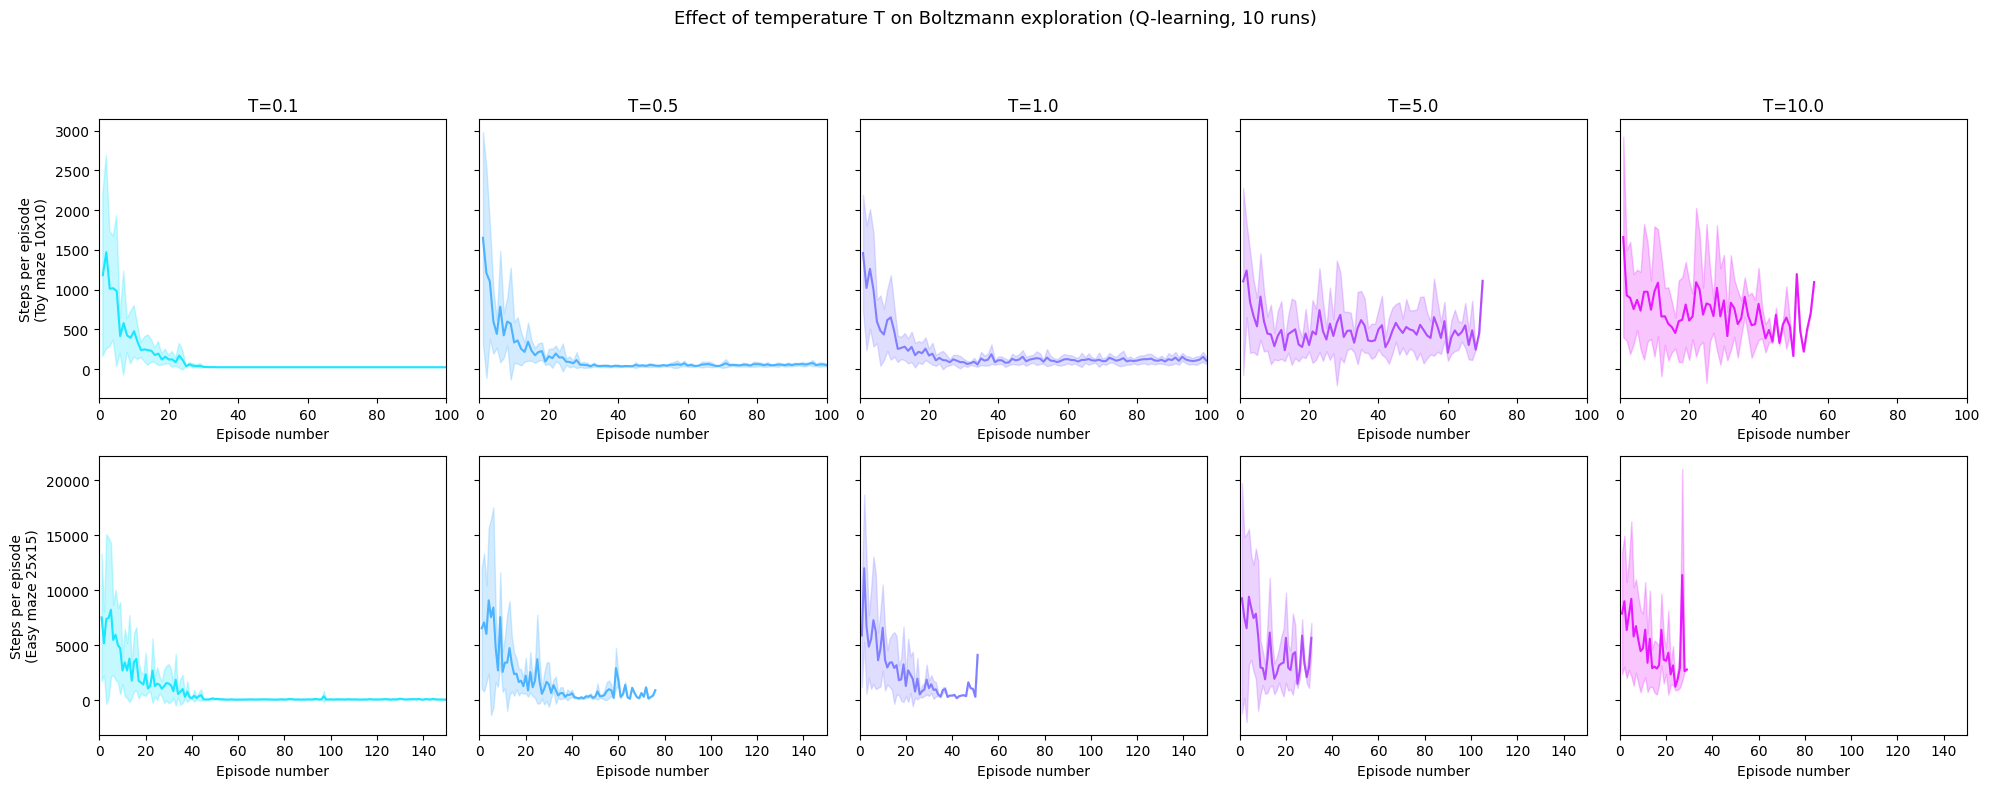

In [18]:
# Varying temperature values for Boltzmann strategy
temperature_values = [0.1, 0.5, 1.0, 5.0, 10.0]

temp_results_toy = {}
temp_results_easy = {}

# For each temperature value, run the experiment and store the results for both mazes
for tv in temperature_values:
    q_table, params = prep_states_action(toy_path, 9, 9)
    learner = make_qlearner(q_table, params)
    temp_results_toy[tv] = run_experiment(
        toy_path, goal_x=9, goal_y=9,
        n_steps=N_STEPS_TOY, n_runs=N_RUNS,
        learner=learner, strategy='boltzmann', temperature=tv
    )

    q_table, params = prep_states_action(easy_path, 24, 14)
    learner = make_qlearner(q_table, params)
    temp_results_easy[tv] = run_experiment(
        easy_path, goal_x=24, goal_y=14,
        n_steps=N_STEPS_EASY, n_runs=N_RUNS,
        learner=learner, strategy='boltzmann', temperature=tv
    )

# Plot: 2 rows (toy, easy) x 5 columns (temperature values)
fig, axes = plt.subplots(2, len(temperature_values), figsize=(20, 8), sharey='row')
colors_temp = plt.cm.cool(np.linspace(0.1, 0.9, len(temperature_values)))

for col, (color, tv) in enumerate(zip(colors_temp, temperature_values)):
    # Toy maze (top row)
    mean, std = pad_and_aggregate(temp_results_toy[tv])
    episodes = np.arange(1, len(mean) + 1)
    axes[0, col].plot(episodes, mean, color=color, linewidth=1.5)
    axes[0, col].fill_between(episodes, mean - std, mean + std, alpha=0.25, color=color)
    axes[0, col].set_title(f'T={tv}')
    axes[0, col].set_xlabel('Episode number')
    axes[0, col].set_xlim(0, 100)

    # Easy maze (bottom row)
    mean, std = pad_and_aggregate(temp_results_easy[tv])
    episodes = np.arange(1, len(mean) + 1)
    axes[1, col].plot(episodes, mean, color=color, linewidth=1.5)
    axes[1, col].fill_between(episodes, mean - std, mean + std, alpha=0.25, color=color)
    axes[1, col].set_xlabel('Episode number')
    axes[1, col].set_xlim(0, 150)

axes[0, 0].set_ylabel('Steps per episode\n(Toy maze 10x10)')
axes[1, 0].set_ylabel('Steps per episode\n(Easy maze 25x15)')
fig.suptitle('Effect of temperature T on Boltzmann exploration (Q-learning, 10 runs)', fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

*The plots show the average steps per episode over 10 runs  with α=0.7, γ=0.9.*

### Impact of T on the Agent

- **T=0.1:** The agent converges fastest and most cleanly across both mazes. The low temperature makes the agent nearly fully greedy it strongly favours the action with the highest Q-value at every step, committing quickly to the best path it has found. The confidence band is wide early but narrows rapidly, indicating consistent convergence across runs.

- **T=0.5:** Very similar behaviour to T=0.1 in the Toy maze, but with a slightly slower initial convergence and marginally higher final step count. A small amount of exploration is introduced but not enough to significantly slow learning. In the Easy Maze convergence is noisy and significantly worse than T=0.1.

- **T=1.0:** Convergence is noticeably slower and the final stable step count is higher than T=0.1 and T=0.5. The agent explores more broadly, which is visible in the wider confidence band and noisier curve. In the easy maze it still converges but takes more episodes to stabilise.

- **T=5.0:** The agent struggles to converge cleanly. In the toy maze the curve drops initially but then becomes noisy and unstable, never fully settling. In the easy maze it converges somewhat but with high variance. At this temperature the probabilities across actions are spread quite evenly, so the agent keeps exploring even when it already has good Q-values.

- **T=10.0:** The worst performance across both mazes. The agent barely converges, steps per episode remain high and highly variable throughout all 100 episodes. At T=10 the action probabilities are nearly uniform regardless of Q-values, meaning the agent behaves almost randomly and cannot exploit what it has learned. 

### Trade-offs Between High and Low T

| | **Low T (e.g. 0.1)** | **High T (e.g. 10.0)** |
|---|---|---|
| **Exploration** | Very little, nearly fully greedy | A lot, nearly uniform random |
| **Exploitation** | Strong, commits to best known action | Weak, ignores Q-value differences |
| **Convergence speed** | Fast | Slow or never |
| **Risk** | May miss better paths if Q-values are not yet accurate early in training | Never commits to learned policy, permanently inflated step count |
| **Sensitivity to Q-values** | High, small Q differences lead to large probability differences | Low, even large Q differences barely affect probabilities |

- A **too-low T** risks premature exploitation if the Q-table is still inaccurate early in training, the agent commits confidently to a suboptimal path and barely explores alternatives.
- A **too-high T** means the agent never benefits from what it has learned the Boltzmann distribution collapses to uniform random, making it equivalent to the random exploration strategy.
- The results suggest **T=0.1 or T=0.5** perform best across both mazes, offering fast and stable convergence without sacrificing early exploration.

#### Question 11: Using your insights from the tuning of ϵ and T, compare the performance of the three exploration strategies. Which one performs best? Why do you think that is the case?

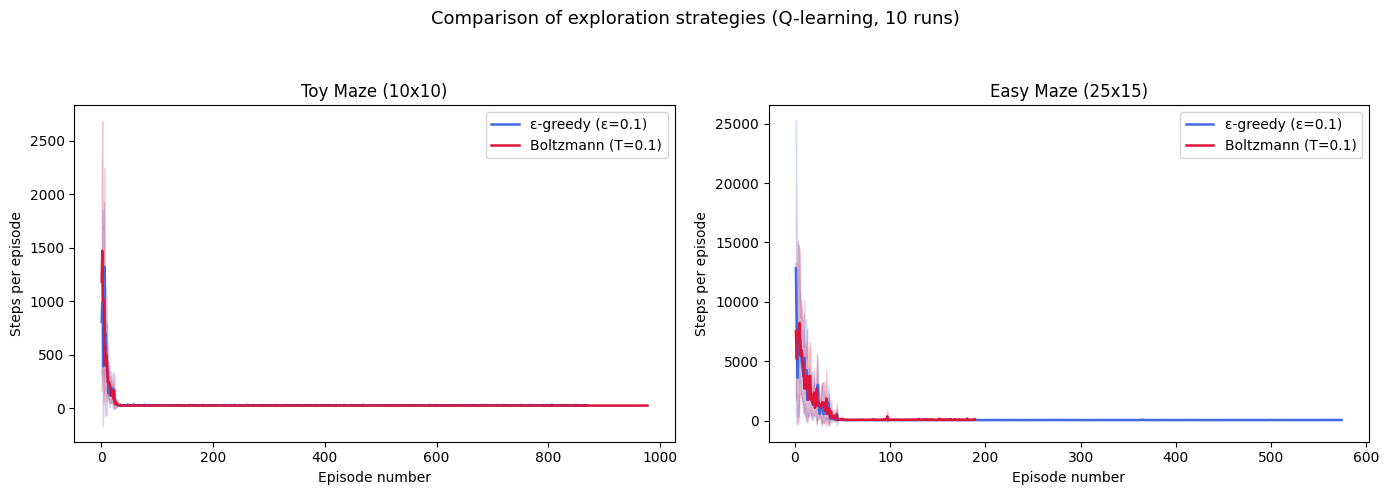

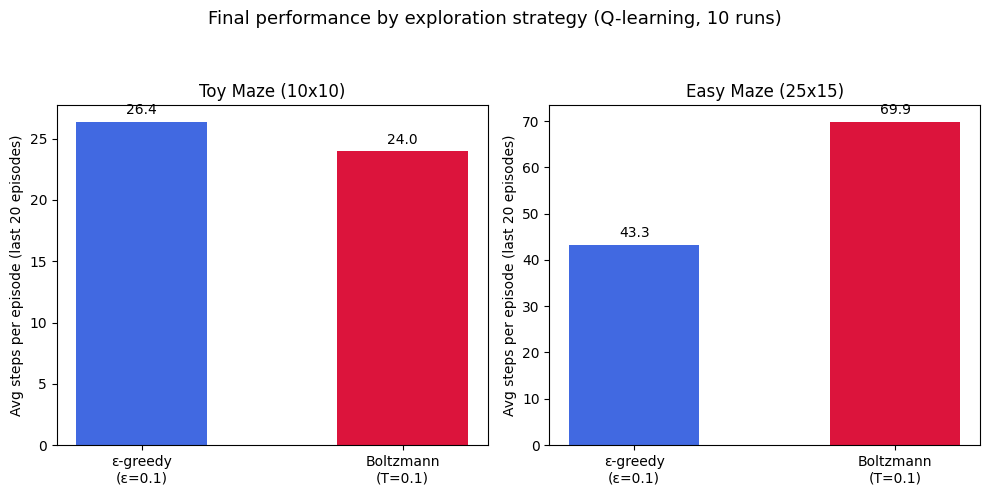

In [19]:
# Using best configs from Q8 (eps=0.1) and Q10 (T=0.1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

strategies = {
    'ε-greedy (ε=0.1)':  (eps_results_toy[0.1],  eps_results_easy[0.1],  'royalblue'),
    'Boltzmann (T=0.1)': (temp_results_toy[0.1], temp_results_easy[0.1], 'crimson'),
}

for ax, maze_label, maze_idx in zip(axes, ['Toy Maze (10x10)', 'Easy Maze (25x15)'], [0, 1]):
    for label, (toy_data, easy_data, color) in strategies.items():
        data = toy_data if maze_idx == 0 else easy_data
        mean, std = pad_and_aggregate(data)
        episodes = np.arange(1, len(mean) + 1)
        ax.plot(episodes, mean, label=label, color=color, linewidth=1.8)
        ax.fill_between(episodes, mean - std, mean + std, alpha=0.2, color=color)
    ax.set_title(maze_label)
    ax.set_xlabel('Episode number')
    ax.set_ylabel('Steps per episode')
    ax.legend()

fig.suptitle('Comparison of exploration strategies (Q-learning, 10 runs)', fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


# Final performance bar chart (avg of last 20 episodes)
def final_performance(data, last_n=20):
    """Uses the aggregated mean curve so all runs are treated consistently."""
    mean, _ = pad_and_aggregate(data)
    return np.mean(mean[-last_n:])

labels = ['ε-greedy\n(ε=0.1)', 'Boltzmann\n(T=0.1)']
colors = ['royalblue', 'crimson']

toy_scores  = [final_performance(eps_results_toy[0.1]),
               final_performance(temp_results_toy[0.1])]

easy_scores = [final_performance(eps_results_easy[0.1]),
               final_performance(temp_results_easy[0.1])]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, scores, maze_label in zip(axes,
                                   [toy_scores, easy_scores],
                                   ['Toy Maze (10x10)', 'Easy Maze (25x15)']):
    bars = ax.bar(labels, scores, color=colors, width=0.5)
    ax.bar_label(bars, fmt='%.1f', padding=3)
    ax.set_title(maze_label)
    ax.set_ylabel('Avg steps per episode (last 20 episodes)')

fig.suptitle('Final performance by exploration strategy (Q-learning, 10 runs)', fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

#### Question 11 — Comparison of Exploration Strategies

*The plots compare the best configurations from Q8 and Q10, using Q-Learning with α=0.7, γ=0.9 across 10 runs.*

From the results of Q8 and Q10, it is clear that **ε-greedy (ε=0.1)** and
**Boltzmann (T=0.1)** are the strongest contenders.

##### Comparison

- Both strategies converge quickly and produce low final step counts. The
learning curves are nearly indistinguishable in both mazes, confirming that
both are effective when well-tuned.

- The bar chart reveals a difference in the mazes:
    - **Toy maze:** Boltzmann (24.0) slightly outperforms ε-greedy (26.4)
    - **Easy maze:** ε-greedy (43.3) clearly outperforms Boltzmann (69.9)

- In the larger easy maze, Boltzmann at T=0.1 is too exploitative too early. 
It converges to a suboptimal path before fully exploring the larger state space.
ε-greedy at ε=0.1 explores more uniformly and finds a better final policy.

##### Which Performs Best?

**ε-greedy (ε=0.1) is the overall winner**, performing competitively in the
toy maze and significantly better in the easy maze. While Boltzmann is
theoretically superior due to its informed exploration, it never wastes steps
on actions the Q-table already knows are bad, this advantage only materialises
when T is carefully tuned per environment. At T=0.1, it is simply too greedy
for larger mazes. ε-greedy with ε=0.1 is more robust across maze sizes and
requires less tuning to achieve strong performance.

#### Question 12: Finally, play around with the learning rate α for QLearning. Again, choose a value of α between 0 and 1 at least five times. Make a plot for each of these values. Explain what you notice. Why is that the case?

NameError: name 'psad_and_aggregate' is not defined

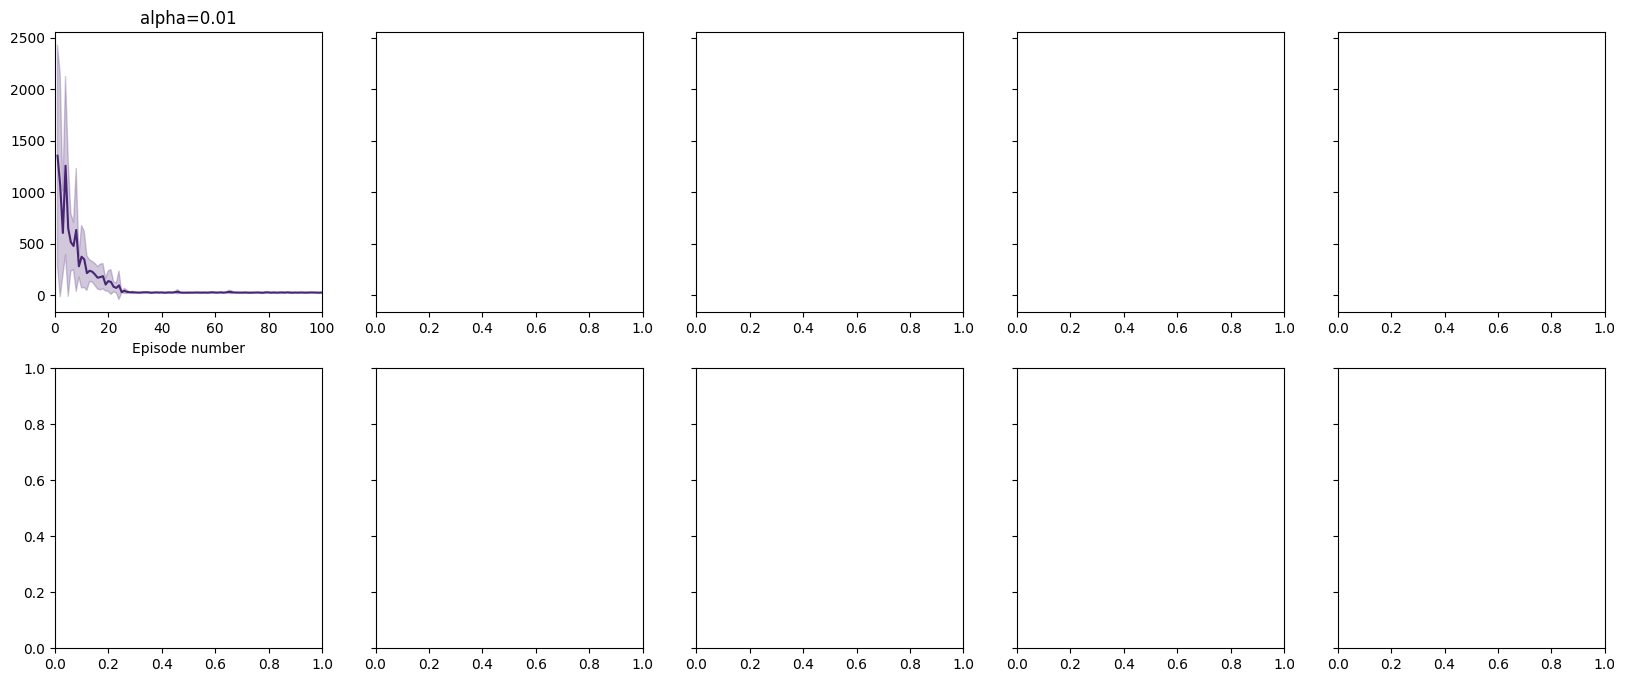

In [20]:
alpha_values = [0.01, 0.1, 0.3, 0.7, 0.9]

alpha_results_toy = {}
alpha_results_easy = {}

# Save the original alpha value to restore later
_alpha_saved = alpha 

for av in alpha_values:
    # override global so QLearning.learn() uses this value
    alpha = av

    q_table, params = prep_states_action(toy_path, 9, 9)
    learner = make_qlearner(q_table, params)
    alpha_results_toy[av] = run_experiment(
        toy_path, goal_x=9, goal_y=9,
        n_steps=N_STEPS_TOY, n_runs=N_RUNS,
        learner=learner, strategy='e_greedy', eps=0.1
    )

    q_table, params = prep_states_action(easy_path, 24, 14)
    learner = make_qlearner(q_table, params)
    alpha_results_easy[av] = run_experiment(
        easy_path, goal_x=24, goal_y=14,
        n_steps=N_STEPS_EASY, n_runs=N_RUNS,
        learner=learner, strategy='e_greedy', eps=0.1
    )

# restore global alpha to original value
alpha = _alpha_saved

# Plot: 2 rows x 5 columns
fig, axes = plt.subplots(2, len(alpha_values), figsize=(20, 8), sharey='row')
colors_alpha = plt.cm.viridis(np.linspace(0.1, 0.9, len(alpha_values)))

for col, (color, av) in enumerate(zip(colors_alpha, alpha_values)):
    mean, std = pad_and_aggregate(alpha_results_toy[av])
    episodes = np.arange(1, len(mean) + 1)
    axes[0, col].plot(episodes, mean, color=color, linewidth=1.5)
    axes[0, col].fill_between(episodes, mean - std, mean + std, alpha=0.25, color=color)
    axes[0, col].set_title(f'alpha={av}')
    axes[0, col].set_xlabel('Episode number')
    axes[0, col].set_xlim(0, 100)

    mean, std = psad_and_aggregate(alpha_results_easy[av])
    episodes = np.arange(1, len(mean) + 1)
    axes[1, col].plot(episodes, mean, color=color, linewidth=1.5)
    axes[1, col].fill_between(episodes, mean - std, mean + std, alpha=0.25, color=color)
    axes[1, col].set_xlabel('Episode number')
    axes[1, col].set_xlim(0, 150)

axes[0, 0].set_ylabel('Steps per episode\n(Toy maze 10x10)')
axes[1, 0].set_ylabel('Steps per episode\n(Easy maze 25x15)')
fig.suptitle('Effect of learning rate alpha on Q-learning (10 runs)', fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

#### Impact of α on the Agent

- **α=0.01:** Surprisingly, the agent converges the fastest and most cleanly across both mazes. Steps per episode drop sharply within the first 10-20 episodes and the confidence band is the narrowest of all configurations, indicating very consistent behaviour across runs. This is counterintuitive, a very low learning rate still converges fast here because the maze is relatively simple and the agent visits the same states many times within the step budget, accumulating small but consistent updates.

- **α=0.1:** Converges cleanly but slightly slower than α=0.01. The early episodes show a higher spike and wider confidence band, stabilising to a low step count after around 20-30 episodes in the toy maze and 50 in the easy maze.

- **α=0.3:** Noticeably noisier than the lower values. The curve drops but with more oscillation before settling, and the confidence band stays wider for longer. In the easy maze the instability is more pronounced, with visible bumps in the curve even after the initial convergence phase.

- **α=0.7:** Similar to α=0.3 but with even more oscillation during convergence. The agent reaches a low final step count but the path there is less stable. The confidence band suggests more variability across runs compared to lower α values.

- **α=0.9:** The most unstable of all configurations. In the toy maze the curve drops fast initially but then oscillates before settling. In the easy maze this instability is amplified, the curve shows several spikes after the initial drop, indicating the aggressive updates are repeatedly overwriting previously learned Q-values with noisy estimates.

#### Explanation

The role of α is directly visible in the Q-learning update equation:

$$Q(s,a) \leftarrow Q(s,a) + \alpha[r + \gamma \max_{a'} Q(s',a') - Q(s,a)]$$

α controls the **weight given to new information versus old estimates**:

- A **low α** means each update makes only a small change to the Q-value.
The agent is conservative and relies heavily on accumulated past experience. In a simple maze visited many times, this is actually very effective updates are small but consistent, leading to stable convergence as seen with α=0.01.

- A **high α** means each new transition nearly overwrites the previous Q-value entirely. The agent reacts very strongly to individual steps, including noisy ones caused by ε-greedy exploration. A single unlucky random action can significantly damage a Q-value that took many episodes to learn correctly, causing the oscillations visible at α=0.7 and α=0.9.

- The key insight from the plots is that **lower α values outperform higher ones** in these mazes, contrary to the intuition that faster updates equal faster learning. The instability introduced by high α outweighs the benefit of faster individual updates, especially in the larger easy maze where the Q-table has more entries to stabilise.

### 2.3 Introducing More Rewards
#### Question 13

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 14: Does switching from QLearning to SARSA help us solve the problem from above? Why?

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 15

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 16

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

## 3. Open Questions
### 3.1 Reflection
#### Question 17: Give at least one downside of an algorithm that is greedy with its action selection.

These are some downsides of an algorithm that is greedy with its action selection:
- **Stuck in local optimal**: Because a greedy algorithm always selects the action that appears best at the current moment (without considering future consequences), it may converge to a suboptimal solution instead of finding the true optimum.
- **Lack of exploration**: A greedy algorithm does not try alternative actions once a preference is formed. If an action is initially underestimated, the algorithm will not try it out again, and thus might miss out better options.
- **Sensitive to initial estimates**: Poor initial value estimates can strongly bias the algorithm and thus early mistakes may lead to consistently choosing suboptimal actions.

#### Question 18: When and why can reward functions cause problems in the society? Think in terms of agents “understanding” the point of their reward functions.

Reward functions can cause problems in society when agents optimise them in unintended ways, effectively "misunderstanding" the true goal behind the optimisation. Since an agent only tries to maximise the reward, it may exploit loopholes or shortcuts that technically increase the reward, but lead to undesirable or harmful outcomes.

An example of is an automonous delivery drone that is rewarded solely for speed in completing deliveries. To maximise th reward, the drone might take unsafe shortcuts, fly in restricted areas or igrnore traffic rules. While the reward function (fast deliveries) is technically satisfied, the true goal of safe and reliable delivery is compromised. This example illustrates that if an agent only focusses on the explicit reward, it can behave in harmful or socially unacceptable ways, even though it is doing a good job when solely looking at the reward function.

#### Question 19: Can you think of a way to overcome these problems for reward functions, used in practice?

One way to overcome these problems is to use multiple objectives alongside the main reward. For example, in the delivery drone scenario, the reward could combine speed of delivery with safety compliance and adherence to regulations. This ensures that maximising the reward requires the agent to balance all desired outcomes, reducing the likelihood of unsafe shortcuts or rule violations.

Another approach is to use human feedback, where an agent's reward is adjusted based on how well its behaviour aligns with human intentions. This helps guid the agent toward actions that achieve the intended goals rather than exploiting loopholes in the reward function.

### 3.2 Pen and Paper
#### Question 20

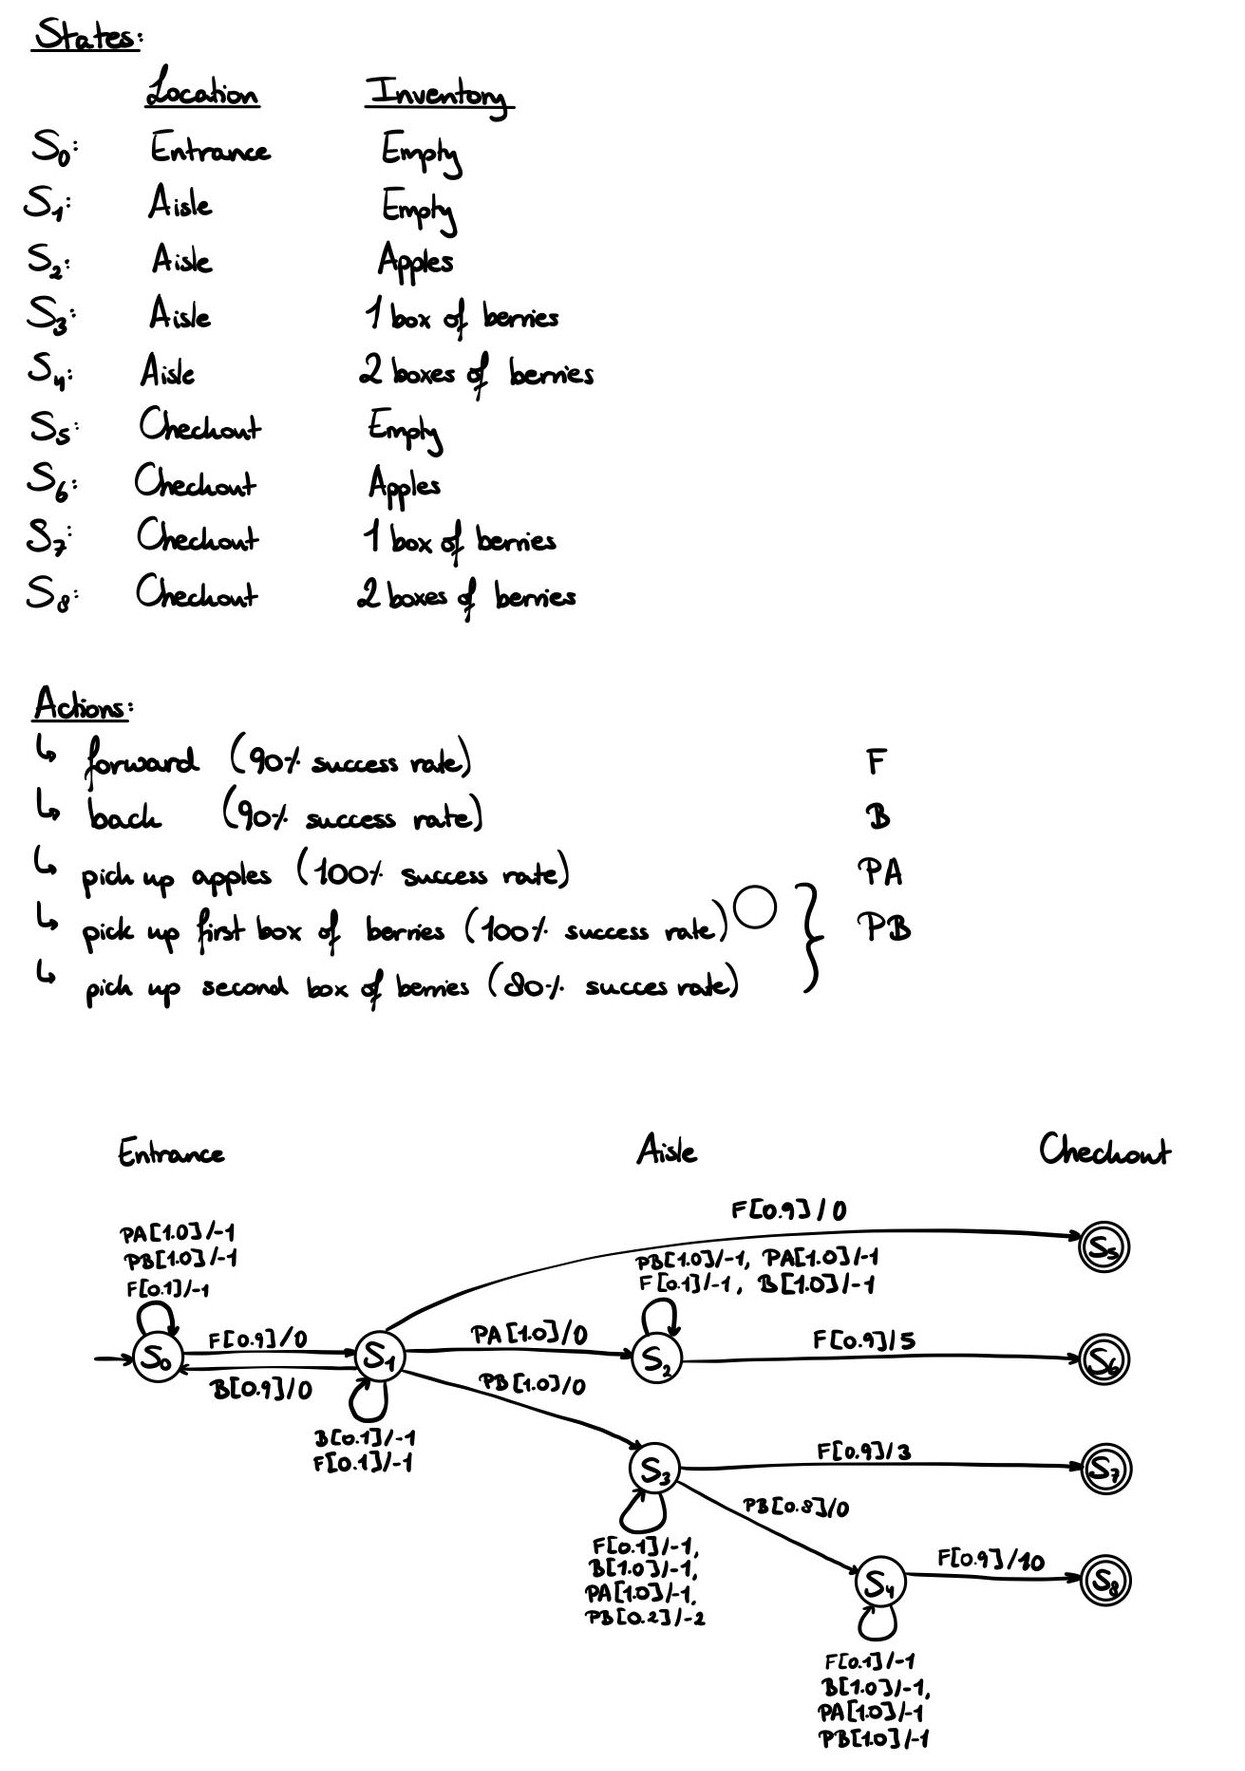

#### Question 21

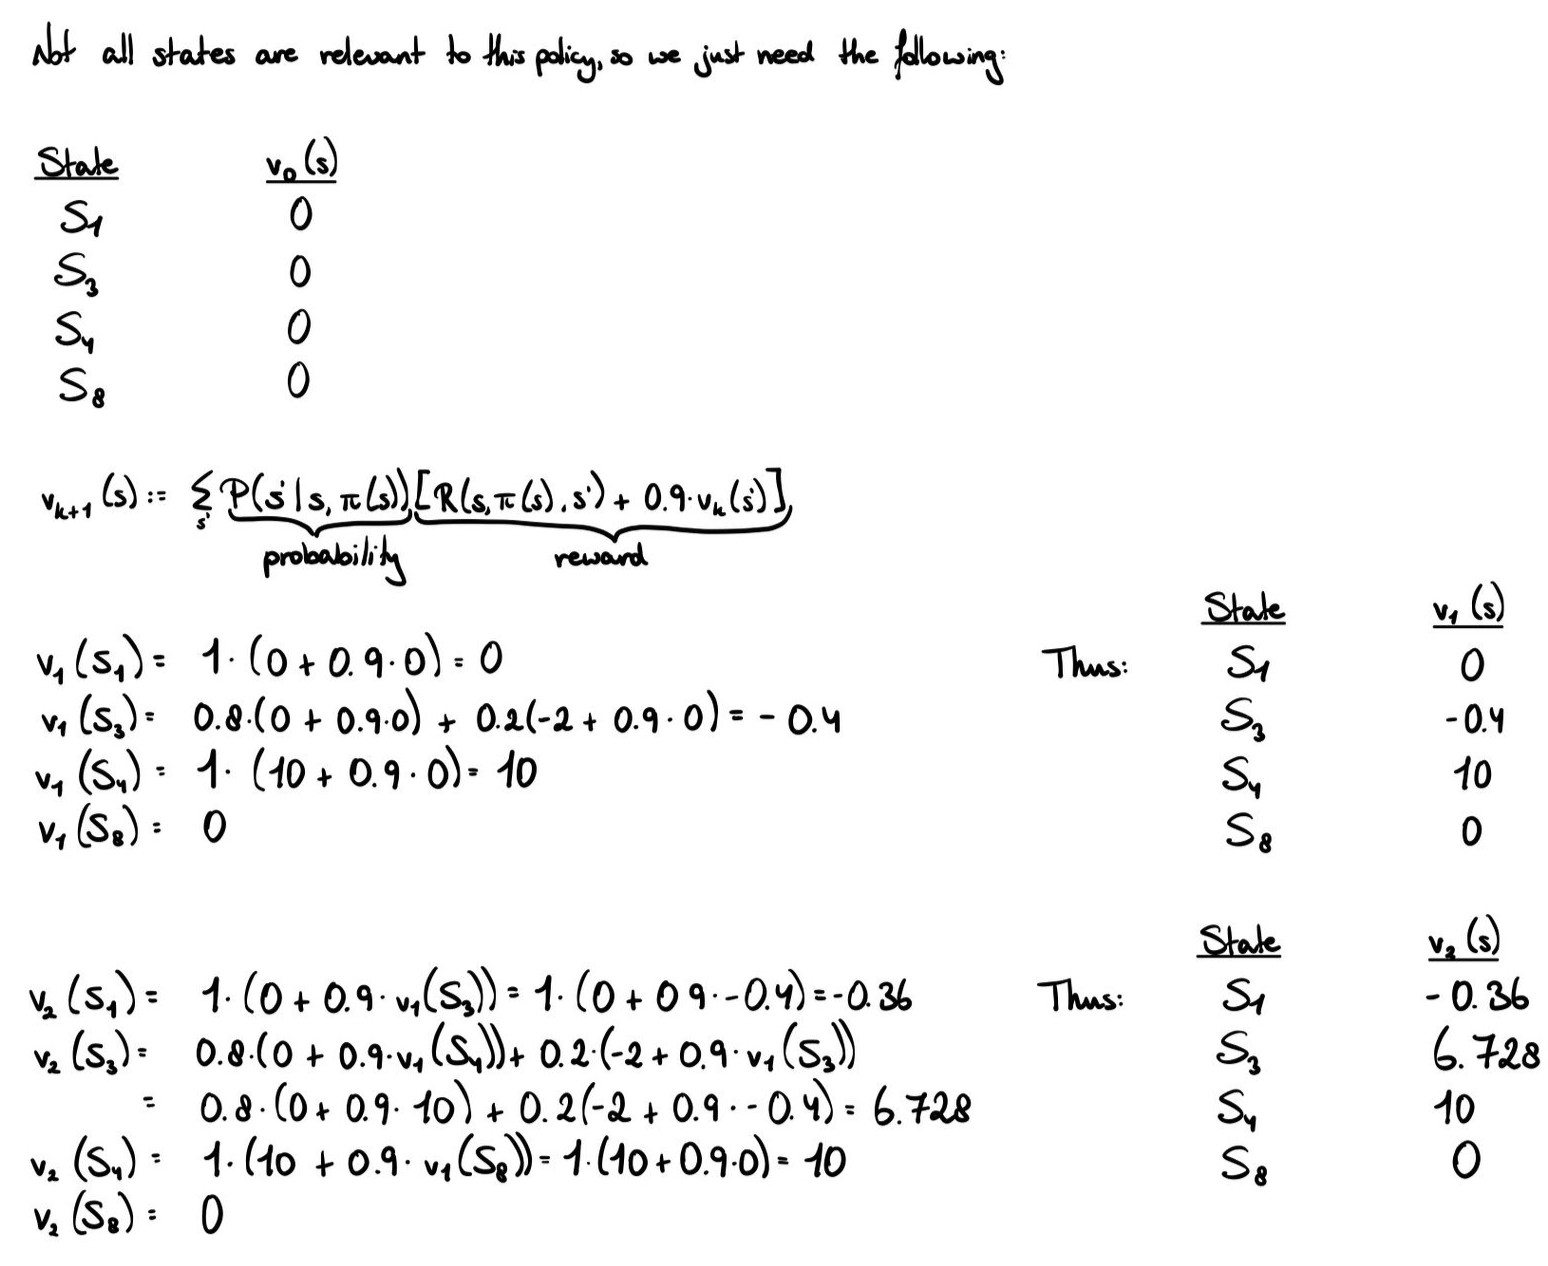

#### Question 22

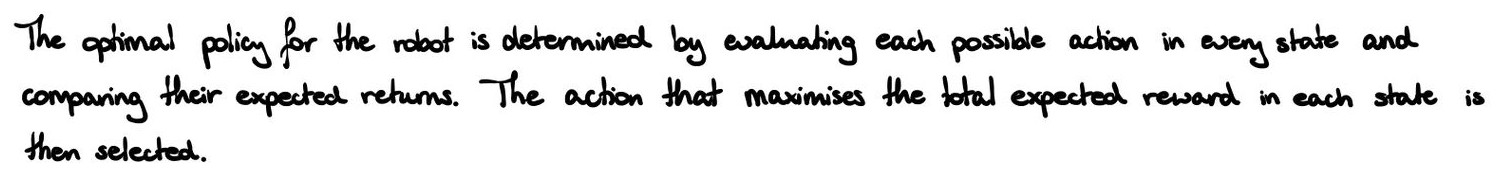

### 3.3 Division of Work

#### Question 23

|          Component          |    Eva    |  Iasonas  |    Guy    |   Miłosz  |
|-----------------------------|-----------|-----------|-----------|----------|
| Code (design)               |    20%    |    30%    |    25%    |    25%   |
| Code (implementation)       |    25%    |    25%    |    30%    |    20%   |
| Code (validation)           |    30%    |    20%    |    25%    |    25%   |
| Experiments (execution)     |    25%    |    25%    |    25%    |    25%   |
| Experiments (analysis)      |    20%    |    30%    |    25%    |    25%   |
| Experiments (visualisation) |    25%    |    25%    |    20%    |    30%   |
| Report (original draft)     |    30%    |    20%    |    25%    |    25%   |
| Report (reviewing & editing)|    25%    |    25%    |    25%    |    25%   |

### References

Generative AI was used for help with the following:
- **Markdown**: for example, making tables in Markdown
- The Held-Karp verification helper (mentioned in the code)
- Assistance with debugging and writing unit tests
- Suggestions (mentioned in the code) and verification that the code is correct
- Assistance for refinement of plots via `matplotlib`
- Used for assistance with documentation such as comments and docstrings

# Assignment Breakdown

| Question | Type | Task | Points |
|----------|------|------|--------|
| **2.1 Development** | **Code + Write** | **Implement exploration strategies, agent cycle, stopping criterion, learning algorithms; verify learning occurs** | **21** |
| Q1 | Code + Write | Implement `random()`, `e_greedy()`, `boltzmann()` in `ExplorationStrategy`; explain implementations and exploration/exploitation handling | 4 |
| Q2 | Code + Write | Implement the agent cycle (select action → execute → update Q-table → repeat); explain why each step is necessary | 3 |
| Q3 | Code + Write | Implement stopping criterion (total steps across episodes ≥ n); verify with n = 30,000 | 2 |
| Q4 | Code + Write | Plot average episode length over 10 runs for each maze; show agent does *not* learn (no learner yet); include uncertainty | 4 |
| Q5 | Code + Write | Implement `learn()` for `QLearning` and `SARSA` using Equations 1.1 and 1.2; set α = 0.7, γ = 0.9, ε = 0.1 | 2 |
| Q6 | Code + Write | Plot average episode length over 10 runs for each algorithm/maze; show agent *does* learn; include uncertainty | 4 |
| Q7 | Write | Compare Q-Learning vs SARSA from plots; explain differences with reference to update equations | 2 |
| **2.2 Optimization** | **Code + Write** | **Tune ε, T, and α; compare exploration strategies** | **10** |
| Q8 | Code + Write | Test at least 5 values of ε ∈ [0, 1]; plot 10-run averages; explain observations | 3 |
| Q9 | Write | Discuss trade-offs between high and low ε | 1 |
| Q10 | Code + Write | Test at least 5 values of T for Boltzmann; discuss trade-offs | 2 |
| Q11 | Code + Write | Compare all three exploration strategies; identify best performer and explain why | 2 |
| Q12 | Code + Write | Test at least 5 values of α ∈ [0, 1]; plot and explain observations | 2 |
| **2.3 Introducing More Rewards** | **Code + Write** | **Add competing reward; analyze convergence issues; derive critical γ** | **8** |
| Q13 | Code + Write | Add reward of 5 at (9, 0); observe and explain behavior | 1 |
| Q14 | Code + Write | Test if SARSA solves the problem; compare and explain | 2 |
| Q15 | Code + Write | Mitigate problem via ε-decay or similar; cite literature; show convergence plot | 3 |
| Q16 | Code + Write | Find γ threshold where smaller reward becomes optimal; confirm experimentally and derive analytically | 2 |
| **3.1 Reflection** | **Write** | **Discuss limitations of greedy policies and reward hacking** | **5** |
| Q17 | Write | Give at least one downside of purely greedy action selection | 1 |
| Q18 | Write | Discuss when/why reward functions can cause societal problems (reward hacking, misalignment) | 2 |
| Q19 | Write | Propose practical solutions to reward function problems | 2 |
| **3.2 Pen and Paper** | **Write** | **MDP modeling and policy evaluation (exam prep)** | **8** |
| Q20 | Write | Draw MDP transition graph for fruit-shopping robot scenario; label states, actions, probabilities | 3 |
| Q21 | Write | Compute $v_2(s)$ via Bellman equation for given policy with γ = 0.9; show $v_0$, $v_1$, $v_2$ | 3 |
| Q22 | Write | Explain (no calculation) how to determine the optimal policy | 2 |
| **3.3 Division of Work** | **Write** | **Document group contributions** | **0** |
| Q23 | Write | Fill in contribution table | 0 |
| **Total** | | | **52** |